# Notebook 03 — Respostas Sugeridas & Playbooks (Item 3)

Notebook gerado para testes.


In [27]:
# CÉLULA 1 — Monta caminhos e encontra a entrada do Notebook 01 (robusto p/ VSCode)

from pathlib import Path
import sys

# 1) Descobre a raiz do repositório (procura uma pasta 'code' para se orientar)
CWD = Path.cwd()

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "code").exists():
            return p
    return start  # fallback

REPO_ROOT = find_repo_root(CWD)

# 2) Candidatos de pastas onde o Notebook 01 pode ter salvo o CSV limpo
CANDIDATE_IN_DIRS = [
    REPO_ROOT / "code" / "notebooks" / "outputs" / "notebook01_outputs",
    REPO_ROOT / "notebooks" / "outputs" / "notebook01_outputs",
    REPO_ROOT / "code" / "notebooks" / "notebook01_outputs",
    REPO_ROOT / "notebook01_outputs",
]

# 3) Seleciona a primeira pasta existente; se nenhuma existir, ficará na primeira (para log claro)
IN_DIR = None
for d in CANDIDATE_IN_DIRS:
    if d.exists():
        IN_DIR = d
        break
if IN_DIR is None:
    IN_DIR = CANDIDATE_IN_DIRS[0]  # mesmo se não existir, para mensagem de erro mais útil

INFILE = IN_DIR / "mensagens_unificadas_limpo.csv"

# 4) Saídas: mantemos no mesmo bloco de outputs do projeto
OUTDIR = REPO_ROOT / "code" / "notebooks" / "outputs" / "notebook03_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

print("✓ Repo root         :", REPO_ROOT)
print("✓ Pasta de entrada  :", IN_DIR)
print("✓ Arquivo de entrada:", INFILE, "| existe:", INFILE.exists())
print("✓ Pasta de saída    :", OUTDIR)

# 5) Falha cedo se a entrada não existir
if not INFILE.exists():
    raise FileNotFoundError(
        f"Arquivo de entrada não encontrado: {INFILE}\n"
        "Rode o Notebook 01 e confirme o export OU ajuste o caminho na CÉLULA 1 "
        "(o notebook já procura em code/notebooks/outputs/notebook01_outputs)."
    )


✓ Repo root         : c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04
✓ Pasta de entrada  : c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook01_outputs
✓ Arquivo de entrada: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook01_outputs\mensagens_unificadas_limpo.csv | existe: True
✓ Pasta de saída    : c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook03_outputs


In [28]:
# CÉLULA 2 — Dependências (VSCode/venv) com pinagens estáveis
# O que faz:
# 1) Define um helper `ensure()` que tenta importar um pacote; se falhar, instala e reimporta.
# 2) Garante versões estáveis para evitar incompatibilidades entre máquinas.
# 3) Não quebra se já estiver tudo instalado.

import sys, subprocess, importlib
from typing import Optional

def ensure(dist_name: str, import_name: Optional[str] = None, version: Optional[str] = None):
    """
    Tenta importar; se não existir, instala via pip e reimporta.
    - dist_name: nome do pacote no PyPI (ex.: 'pandas', 'Unidecode')
    - import_name: nome do módulo para import (ex.: 'pandas', 'unidecode'). Se None, usa dist_name.
    - version: string com comparador (ex.: '==2.2.2', '>=1.3'). Se None, instala sem versão.
    """
    mod_name = import_name or dist_name
    try:
        return importlib.import_module(mod_name)
    except Exception:
        # monta comando pip
        pkg = dist_name + (version or "")
        cmd = [sys.executable, "-m", "pip", "install", "-q", pkg]
        print(f"[deps] instalando: {pkg} …")
        try:
            subprocess.run(cmd, check=True)
        except subprocess.CalledProcessError as e:
            print(f"[deps] falhou ao instalar {pkg}: {e}")
            raise
        # reimporta
        return importlib.import_module(mod_name)

# Pacotes com versões fixas
pandas     = ensure("pandas", version="==2.2.2")
numpy      = ensure("numpy")  # pode variar, costuma funcionar bem nas últimas
matplotlib = ensure("matplotlib", version="==3.8.4")
seaborn    = ensure("seaborn", version="==0.13.2")
ftfy       = ensure("ftfy", version="==6.2")
unidecode  = ensure("Unidecode", import_name="unidecode", version="==1.3.8")

# só para logs rápidos
print("✓ deps prontas:",
      "pandas", pandas.__version__,
      "| numpy", numpy.__version__)


✓ deps prontas: pandas 2.3.2 | numpy 2.3.3


In [ ]:
# CÉLULA 3 — NLP: prepara spaCy PT (se possível) e recursos NLTK; define seed langdetect

_spacy_ready = False
try:
    import spacy
    try:
        # Tenta carregar o modelo de português do spaCy.
        nlp = spacy.load("pt_core_news_sm")
        _spacy_ready = True
    except Exception:
        # Se falhar, tenta baixar o modelo de português.
        subprocess.run([sys.executable, "-m", "spacy", "download", "pt_core_news_sm"], check=False)
        try:
            # Tenta carregar o modelo novamente após o download.
            nlp = spacy.load("pt_core_news_sm")
            _spacy_ready = True
        except Exception:
            _spacy_ready = False
    if _spacy_ready:
        # Remove a instância 'nlp' para liberar memória e confirma o carregamento.
        del nlp
        print("✓ spaCy PT OK (pt_core_news_sm).")
    else:
        print("Aviso: spaCy PT não disponível — usaremos fallback NLTK.")
except Exception as e:
    print("Aviso: spaCy não disponível — usaremos fallback NLTK.", e)

# NLTK recursos
try:
    import nltk
    # Baixa recursos essenciais do NLTK para stemming e tokenização.
    nltk.download("rslp", quiet=True)
    nltk.download("punkt", quiet=True)
except Exception:
    pass

# langdetect seed
try:
    # Importa e define uma semente para o DetectorFactory para garantir resultados determinísticos.
    from langdetect import DetectorFactory
    DetectorFactory.seed = 42
except Exception:
    pass

Aviso: spaCy não disponível — usaremos fallback NLTK. No module named 'spacy'


In [30]:
# CÉLULA 4 — Imports, estilo visual e seeds

import pandas as pd, numpy as np, re, json, datetime as dt
import matplotlib.pyplot as plt, seaborn as sns
from unidecode import unidecode

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)
np.random.seed(42)

print("✓ Versões:", "pandas", pd.__version__, "| numpy", np.__version__)


✓ Versões: pandas 2.3.2 | numpy 2.3.3


In [31]:
# CÉLULA 5 — Funções utilitárias de texto (normalize, basic_clean, norm_match)

def normalize_text(s: str) -> str:
    """Corrige encoding (ftfy), remove NUL, contrai espaços e aparas."""
    if not isinstance(s, str):
        return ""
    s = s.replace("\x00", " ")
    try:
        import ftfy
        s = ftfy.fix_text(s)
    except Exception:
        pass
    return re.sub(r"\s+", " ", s).strip()

def basic_clean(s: str) -> str:
    """Limpeza leve para ML/regex: lower, remove URLs/menções e pontuação pesada."""
    s = normalize_text(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"[@#]\w+", " ", s)
    s = re.sub(r"[^\w\sáéíóúâêôãõç]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def norm_match(s: str) -> str:
    """ASCII + lower p/ regex robusta (independente de acentos)."""
    return unidecode(normalize_text(s)).lower()


In [32]:
# CÉLULA 6 — Lê o CSV do NB01, cria colunas mínimas e normaliza campos

df = pd.read_csv(INFILE)

for c in ["ts","autor","texto","origem","arquivo_origem","lado"]:
    if c not in df.columns:
        df[c] = pd.NA

df["texto"] = df["texto"].astype(str).map(normalize_text)
df["lado"]  = df["lado"].fillna("cliente")

print("Linhas totais           :", len(df))
print("Nulos em 'texto'        :", int(df["texto"].eq("").sum()))
print("Valores únicos 'origem' :", df["origem"].dropna().unique()[:10])
print("Valores únicos 'lado'   :", df["lado"].dropna().unique())
df.head(5)


Linhas totais           : 2073
Nulos em 'texto'        : 0
Valores únicos 'origem' : ['instagram_csv' 'instagram_zip']
Valores únicos 'lado'   : ['cliente' 'time']


,ts,autor,texto,origem,arquivo_origem,lado,dia,texto_clean2
0,2024-07-02 12:29:00.000,biapaesdebarros_1418872999507501,😍,instagram_csv,Consolidação das mensagens do INSTAGRAM.csv,cliente,2024-07-02,NaN
1,2024-07-02 12:29:00.000,brendaluchese_1482641736467533,😍 body mybasic,instagram_csv,Consolidação das mensagens do INSTAGRAM.csv,cliente,2024-07-02,body mybasic
2,2024-07-07 18:32:00.000,emiliafreitas_1320876775966156,"oi bia, tudo bem? adorei a @curadabia, (o nome ficou demais), e claro ja fui olhar as peças! não localizei tabela de medidas! porem, pelo tamanho das peças que vc veste o g provavelmente não vai c...",instagram_csv,Consolidação das mensagens do INSTAGRAM.csv,cliente,2024-07-07,bem adorei ficou demais claro fui olhar peças localizei tabela medidas porem tamanho peças veste provavelmente vai caber mim uso depender confecção pense carinho curadoria tamanhos normais desejo ...
3,2024-07-08 19:21:00.000,brendaluchese_1482641736467533,https://www.instagram.com/_nata.oficial?igsh=n204dxp5bzn6azbz,instagram_csv,Consolidação das mensagens do INSTAGRAM.csv,cliente,2024-07-08,NaN
4,2024-07-08 19:40:00.000,emiliafreitas_1320876775966156,"olá emilia, boa noite! tudo bem? agradecemos demais o feedback e pode ter certeza que uma das preocupações que estamos tendo é seguir na busca por marcas que tragam opções e grades que representam...",instagram_csv,Consolidação das mensagens do INSTAGRAM.csv,time,2024-07-08,NaN


In [33]:
# CÉLULA 7 — Marca ruídos/auto-eventos e remove duplicatas leves

def _norm_ascii_lower(s: str) -> str:
    return unidecode(str(s or "")).lower().strip()

NAME_TOKEN = r"[\w@._]+"
PREFIX     = rf"^\s*(?:{NAME_TOKEN}\s+){{0,5}}"
END_PUNCT  = r"(?:\W|_)*\s*$"

NOISE_PHRASES_RE = re.compile("|".join([
    r"^\s*\[?\s*sem\s+conteudo\s+detectavel\s*\]?\s*\.?\s*$",
    PREFIX + r"sent\s+(?:an?\s+)?attachment\b" + END_PUNCT,
    PREFIX + r"attachment\s+(?:was\s+)?sent\b"   + END_PUNCT,
    PREFIX + r"(?:shared|compartilhou)\s+(?:a\s+)?(?:product|produto|link|post)\b",
    r"\bmedia\s+omitted\b",
    r"\b(this\s+message\s+was\s+deleted|mensagem\s+apagada)\b",
    PREFIX + r"(?:reagiu|reacted)\s+(?:a\s+)?(?:uma?\s+)?mensagem\b",
    PREFIX + r"(?:curtiu|liked)\s+(?:a\s+)?mensagem\b",
    r"\b(?:voice|video)\s+call\b.*\b(?:missed|perdida)\b",
    PREFIX + r"(?:enviou|mandou)\s+(?:um[a]?\s+)?(?:anexo|arquivo|imagem|foto|video|audio|sticker|figurinha)\b" + END_PUNCT,
    PREFIX + r"(?:added|adicionou)\s+.+\b(?:to|ao|à)\s+(?:group|grupo|chat)\b",
    PREFIX + r"(?:changed|alterou)\s+(?:the\s+)?(?:subject|assunto)\b",
]), flags=re.IGNORECASE)

NOISE_TOKEN_SET = {
    "sem","conteudo","detectavel","link","compartilhado","shared","product","produto","post",
    "sent","attachment","imagem","foto","video","audio","sticker","figurinha","enviada","enviado","enviou","mandou",
    "reagiu","mensagem","liked","message","media","omitted","voice","call","missed","perdida","deleted","apagada",
    "added","adicionou","group","grupo","chat","changed","alterou","subject","assunto"
}
NAMELIKE = re.compile(rf"^{NAME_TOKEN}$")

def _strip_leading_namelikes(tokens, max_drop=3):
    out, dropped = list(tokens), 0
    while out and dropped < max_drop and NAMELIKE.match(out[0]):
        out.pop(0); dropped += 1
    return out

def is_noise_event(s: str) -> bool:
    if not isinstance(s, str) or not s.strip():
        return True
    t = _norm_ascii_lower(s)
    if NOISE_PHRASES_RE.search(t):
        return True
    toks = _strip_leading_namelikes(t.split())
    return bool(toks) and set(toks).issubset(NOISE_TOKEN_SET)

df["flag_ruido"] = df["texto"].map(is_noise_event)

df = (df
      .assign(texto_norm=lambda d: d["texto"].str.lower().str.strip())
      .drop_duplicates(subset=["autor","texto_norm"], keep="first")
      .drop(columns=["texto_norm"])
      .copy())

df_cli_pp  = df[df["lado"].eq("cliente")].copy()
df_resp_pp = df[df["lado"].ne("cliente")].copy()

print(f"✓ Pós-filtragem/dedupe: total={len(df)} | cliente={len(df_cli_pp)} | time={len(df_resp_pp)}")
df[["ts","autor","texto","flag_ruido"]].head(5)


✓ Pós-filtragem/dedupe: total=1999 | cliente=1025 | time=974


,ts,autor,texto,flag_ruido
0,2024-07-02 12:29:00.000,biapaesdebarros_1418872999507501,😍,False
1,2024-07-02 12:29:00.000,brendaluchese_1482641736467533,😍 body mybasic,False
2,2024-07-07 18:32:00.000,emiliafreitas_1320876775966156,"oi bia, tudo bem? adorei a @curadabia, (o nome ficou demais), e claro ja fui olhar as peças! não localizei tabela de medidas! porem, pelo tamanho das peças que vc veste o g provavelmente não vai c...",False
3,2024-07-08 19:21:00.000,brendaluchese_1482641736467533,https://www.instagram.com/_nata.oficial?igsh=n204dxp5bzn6azbz,False
4,2024-07-08 19:40:00.000,emiliafreitas_1320876775966156,"olá emilia, boa noite! tudo bem? agradecemos demais o feedback e pode ter certeza que uma das preocupações que estamos tendo é seguir na busca por marcas que tragam opções e grades que representam...",False


In [34]:
# CÉLULA 8 — Limpeza final de ruído e checagens rápidas

def is_noise_final(s: str) -> bool:
    if not isinstance(s, str) or not s.strip():
        return True
    t = norm_match(s)
    if NOISE_PHRASES_RE.search(t):
        return True
    toks = _strip_leading_namelikes(t.split())
    return bool(toks) and set(toks).issubset(NOISE_TOKEN_SET)

_before = len(df)
df = df[~df["texto"].apply(is_noise_final)].copy()
print(f"✓ Removidas {_before - len(df)} linhas de ruído. Restantes: {len(df)}")

for t in ["conteudo detectavel","sent attachment","attachment sent",
          "shared product","reagiu mensagem","media omitted"]:
    c = df["texto"].str.contains(t, case=False, na=False).sum()
    print(f"check '{t}':", c)

df_cli_pp  = df[df["lado"].eq("cliente")].copy()
df_resp_pp = df[df["lado"].ne("cliente")].copy()


✓ Removidas 0 linhas de ruído. Restantes: 1999
check 'conteudo detectavel': 0
check 'sent attachment': 0
check 'attachment sent': 0
check 'shared product': 0
check 'reagiu mensagem': 0
check 'media omitted': 0


In [35]:
# CÉLULA 9 — Detecção de idioma (PT) e stopwords de domínio
# O que esta célula faz:
# 1) Garante 'langdetect' instalado (via ensure) e configura a semente para resultados determinísticos.
# 2) Define 'detect_lang_safe' para detecção robusta (retorna ('und', 0.0) em textos muito curtos/ruído).
# 3) Aplica detecção de idioma nos dataframes de cliente e time (se existirem).
# 4) Define stopwords de domínio (reutilizadas por células posteriores).

# Requisitos: execute a CÉLULA 2 (ensure) antes desta. Também requer que df, df_cli_pp e df_resp_pp existam (CÉLULAS 6–8).

# 1) Garantir 'langdetect' disponível
langdetect = ensure("langdetect", import_name="langdetect", version="==1.0.9")
from langdetect import detect, DetectorFactory

# semente determinística
DetectorFactory.seed = 42

import re
from unidecode import unidecode

def detect_lang_safe(s: str) -> tuple[str, float]:
    """
    Retorna (lang, score) simplificado.
    Heurística:
      - strings curtas/emoji → ('und', 0.0)
      - exceções → ('und', 0.0)
      - sucesso → (lang, 1.0)
    """
    s2 = str(s or "").strip()
    if len(s2) < 3 or re.fullmatch(r"[\W_]+", s2):
        return ("und", 0.0)
    try:
        lang = detect(s2)
        return (lang, 1.0)
    except Exception:
        return ("und", 0.0)

# 2) Anotar idioma (quando houver dados)
for name, _df in [("clientes", df_cli_pp if 'df_cli_pp' in globals() else None),
                  ("time",     df_resp_pp if 'df_resp_pp' in globals() else None)]:
    if _df is None or _df.empty:
        continue
    lang_info = _df["texto"].map(detect_lang_safe)
    _df["lang"]   = lang_info.map(lambda x: x[0])
    _df["lscore"] = lang_info.map(lambda x: x[1])
    print(f"✓ Idioma anotado em {_df.shape[0]} linhas para {name}.")

# 3) Stopwords de domínio (PT + termos do negócio)
STOP = set("""
a ao aos as até com como da das de dela delas dele deles do dos e é em entre era eram essa esse isso eu ela elas ele eles
então esta está estão estou foi foram fomos fazer gostaria hoje ir já la lá mais mas me minha minhas meu meus na nas não
no nos nós o os ou para pela pelas pelo pelos por porque pra quando quê qual que queria se sem sim sobre sua suas
também tem ter tenho tirar tive tô tudo um uma umas uns vc você voces vocês vou obg obrigada obrigado valeu oi olá bom
dia boa tarde boa noite tchau até logo
""".split())
STOP |= set(map(str, range(100))) | {"kkk","rs","rsrs","aff"}
STOP |= {"curadobia","bia","ana","equipe","site","contato","aqui","estamos","qualquer","disposicao",
         "sigo","paes","barros","instagram","nome","trabalho","junto",
         "curtiu","mensagem","compartilhado","compartilhou","enviada","enviado","sent","attachment",
         "shared","product","link","message","media","omitted","deleted","voice","video","call","post"}
print(f"✓ Stopwords de domínio definidas: {len(STOP)} termos.")


✓ Idioma anotado em 1025 linhas para clientes.
✓ Idioma anotado em 974 linhas para time.
✓ Stopwords de domínio definidas: 250 termos.


Com timestamp (df): 1999
Janela temporal (df): 2024-07-02 12:29:00 → 2025-05-19 14:24:34.886000


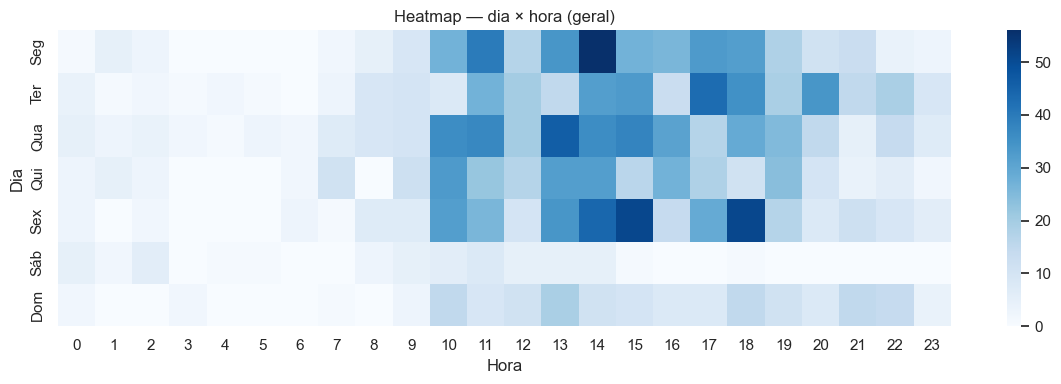

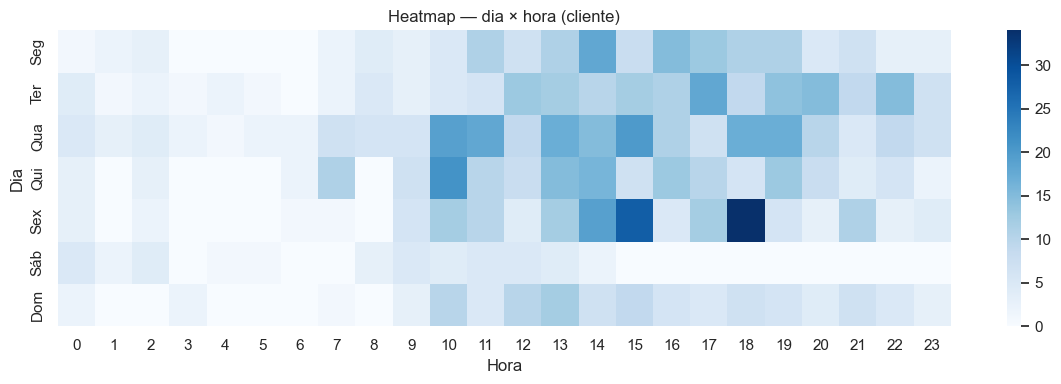

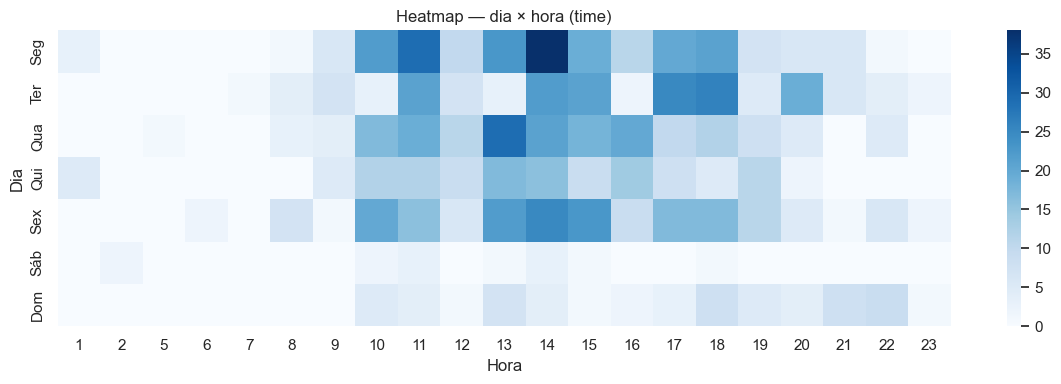

In [36]:
# CÉLULA 10 — Converte ts + cria heatmaps (geral/cliente/time)

df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
print("Com timestamp (df):", int(df["ts"].notna().sum()))
print("Janela temporal (df):", df["ts"].min(), "→", df["ts"].max())

dow_map = {0:"Seg",1:"Ter",2:"Qua",3:"Qui",4:"Sex",5:"Sáb",6:"Dom"}

def plot_heatmap(df_sub, tag: str):
    if "ts" not in df_sub.columns:
        print(f"(sem coluna 'ts' para {tag})")
        return
    tmp = df_sub.copy()
    tmp["ts"] = pd.to_datetime(tmp["ts"], errors="coerce")
    tmp = tmp.dropna(subset=["ts"])
    if tmp.empty:
        print(f"(sem timestamps válidos para {tag})"); return
    tmp["dow"]  = tmp["ts"].dt.dayofweek.map(dow_map).fillna("NA")
    tmp["hour"] = tmp["ts"].dt.hour
    pivot = (tmp.pivot_table(index="dow", columns="hour", values="texto", aggfunc="count")
             .reindex(["Seg","Ter","Qua","Qui","Sex","Sáb","Dom"])
             .fillna(0))
    plt.figure(figsize=(12,4))
    sns.heatmap(pivot, cmap="Blues", cbar=True)
    plt.title(f"Heatmap — dia × hora ({tag})"); plt.xlabel("Hora"); plt.ylabel("Dia")
    plt.tight_layout()
    try: plt.savefig(OUTDIR / f"heatmap_dia_hora_{tag}.png", dpi=150, bbox_inches="tight")
    except: pass
    plt.show()

plot_heatmap(df, "geral")
plot_heatmap(df_cli_pp, "cliente")
plot_heatmap(df_resp_pp, "time")


In [37]:
# CÉLULA 11 — Lematização/tokenização PT-BR (spaCy preferido; fallback NLTK RSLP)
# O que esta célula faz:
# 1) Tenta usar spaCy + modelo 'pt_core_news_sm' (instala se necessário).
# 2) Se spaCy ou o modelo não estiverem disponíveis, cai para NLTK + RSLPStemmer (instala e baixa recursos).
# 3) Escreve a função lemmatize_pt() baseada no backend disponível.
# 4) Gera colunas 'mensagem_lemma' e 'len_tokens' para CLIENTE e TIME.
# Requisitos: CÉLULA 2 (ensure), CÉLULA 9 (STOP), CÉLULAS 6–8 (df_cli_pp/df_resp_pp).

import re

def tokenize_keep_tags(s: str):
    """Mantém tags <url> <user> <num> como tokens para não perder informação."""
    return re.findall(r"<\w+>|\w+", str(s))

LEMM_MODE = None
nlp = None

# 1) Tentar spaCy + modelo PT
try:
    spacy = ensure("spacy", import_name="spacy", version="==3.7.4")
    try:
        nlp = spacy.load("pt_core_news_sm")
    except Exception:
        # tentar baixar o modelo pt_core_news_sm
        import subprocess, sys
        try:
            subprocess.run([sys.executable, "-m", "spacy", "download", "pt_core_news_sm", "-q"],
                           check=True)
            nlp = spacy.load("pt_core_news_sm")
        except Exception as e:
            nlp = None
            print("Aviso: não foi possível carregar/baixar 'pt_core_news_sm'. Fallback para NLTK. (", e, ")")
except Exception as e:
    nlp = None
    print("Aviso: spaCy indisponível. Fallback para NLTK. (", e, ")")

if nlp is not None:
    LEMM_MODE = "spacy"
    def lemmatize_pt(s: str) -> str:
        doc = nlp(str(s))
        toks = []
        for w in doc:
            if (w.is_space or w.is_punct or w.like_num):
                continue
            t = w.lemma_.lower().strip()
            if t and len(t) > 1 and t not in STOP:
                toks.append(t)
        return " ".join(toks)
else:
    # 2) Fallback NLTK + RSLP
    nltk = ensure("nltk", import_name="nltk", version="==3.8.1")
    from nltk.stem import RSLPStemmer
    try:
        import nltk as _nltk
        _nltk.download("rslp", quiet=True)
        _nltk.download("punkt", quiet=True)
    except Exception:
        pass
    stemmer = RSLPStemmer()
    LEMM_MODE = "rslp-stem"
    def lemmatize_pt(s: str) -> str:
        toks = [w for w in tokenize_keep_tags(s) if w.isalpha() and w.lower() not in STOP and len(w) > 1]
        toks = [stemmer.stem(w.lower()) for w in toks]
        return " ".join(toks)

# 3) Aplicar no CLIENTE e TIME (apenas PT/indefinido)
for name, _df in [('clientes', df_cli_pp if 'df_cli_pp' in globals() else None),
                  ('time',     df_resp_pp if 'df_resp_pp' in globals() else None)]:
    if _df is None or _df.empty:
        continue
    _is_ptish = _df.get("lang", "und")
    _is_ptish = _df["lang"].fillna("und").isin(["pt","und"]) if "lang" in _df.columns else pd.Series([True]*len(_df))
    _df["mensagem_norm"] = _df["texto"]
    _df.loc[_is_ptish, "mensagem_lemma"] = _df.loc[_is_ptish, "mensagem_norm"].map(lemmatize_pt)
    _df["len_tokens"] = _df["mensagem_lemma"].fillna("").str.split().map(len)

print("✓ Lematização usada:", LEMM_MODE)
display(df_cli_pp[["ts","autor","mensagem_lemma","len_tokens"]].head(5) if 'df_cli_pp' in globals() and not df_cli_pp.empty else "Sem dados de cliente para mostrar.")


[deps] instalando: spacy==3.7.4 …
[deps] falhou ao instalar spacy==3.7.4: Command '['c:\\Users\\win\\AppData\\Local\\Programs\\Python\\Python313\\python.exe', '-m', 'pip', 'install', '-q', 'spacy==3.7.4']' returned non-zero exit status 1.
Aviso: spaCy indisponível. Fallback para NLTK. ( Command '['c:\\Users\\win\\AppData\\Local\\Programs\\Python\\Python313\\python.exe', '-m', 'pip', 'install', '-q', 'spacy==3.7.4']' returned non-zero exit status 1. )
[deps] instalando: nltk==3.8.1 …
✓ Lematização usada: rslp-stem


,ts,autor,mensagem_lemma,len_tokens
0,2024-07-02 12:29:00.000,biapaesdebarros_1418872999507501,,0
1,2024-07-02 12:29:00.000,brendaluchese_1482641736467533,NaN,0
2,2024-07-07 18:32:00.000,emiliafreitas_1320876775966156,bem ador curadab fic demal clar ja fui olh peç localiz tabel med por tamanh peç vest prova vai cab mim uso depend confecç pens car curad tamanh norm desej muit sucess ness nov empreit deu te abenç...,39
3,2024-07-08 19:21:00.000,brendaluchese_1482641736467533,http www ofic igsh,4
5,2024-07-09 08:20:00.000,emiliafreitas_1320876775966156,NaN,0


In [38]:
# CÉLULA 12 — Filtra cliente e cria 'texto_ml'

df_cli = df[df["lado"].astype(str).str.lower().eq("cliente")].copy().reset_index(drop=True)
df_cli["texto_ml"] = df_cli["texto"].map(basic_clean)

print("Registros (cliente):", len(df_cli))
df_cli.head(5)


Registros (cliente): 1025


,ts,autor,texto,origem,arquivo_origem,lado,dia,texto_clean2,flag_ruido,texto_ml
0,2024-07-02 12:29:00,biapaesdebarros_1418872999507501,😍,instagram_csv,Consolidação das mensagens do INSTAGRAM.csv,cliente,2024-07-02,NaN,False,
1,2024-07-02 12:29:00,brendaluchese_1482641736467533,😍 body mybasic,instagram_csv,Consolidação das mensagens do INSTAGRAM.csv,cliente,2024-07-02,body mybasic,False,body mybasic
2,2024-07-07 18:32:00,emiliafreitas_1320876775966156,"oi bia, tudo bem? adorei a @curadabia, (o nome ficou demais), e claro ja fui olhar as peças! não localizei tabela de medidas! porem, pelo tamanho das peças que vc veste o g provavelmente não vai c...",instagram_csv,Consolidação das mensagens do INSTAGRAM.csv,cliente,2024-07-07,bem adorei ficou demais claro fui olhar peças localizei tabela medidas porem tamanho peças veste provavelmente vai caber mim uso depender confecção pense carinho curadoria tamanhos normais desejo ...,False,oi bia tudo bem adorei a o nome ficou demais e claro ja fui olhar as peças não localizei tabela de medidas porem pelo tamanho das peças que vc veste o g provavelmente não vai caber em mim uso 46 4...
3,2024-07-08 19:21:00,brendaluchese_1482641736467533,https://www.instagram.com/_nata.oficial?igsh=n204dxp5bzn6azbz,instagram_csv,Consolidação das mensagens do INSTAGRAM.csv,cliente,2024-07-08,NaN,False,
4,2024-07-09 08:20:00,emiliafreitas_1320876775966156,obrigada! beijinhos,instagram_csv,Consolidação das mensagens do INSTAGRAM.csv,cliente,2024-07-09,beijinhos,False,obrigada beijinhos


In [39]:
# CÉLULA 13 — Taxonomia (intenção → definição) + prioridade + export JSON

TAXONOMIA = {
    "saudacao":        "Saudar/iniciar conversa (oi, olá, bom dia, boa tarde, boa noite).",
    "agradecimento":   "Agradecer/elogiar (obrigada, valeu, amei, parabéns).",
    "despedida":       "Encerrar conversa (tchau, até logo, até mais).",
    "duvida_tamanho":  "Perguntas sobre medidas, numeração, servir/caber, PP–GG.",
    "pedido_sugestao": "Pedir sugestão de looks/combinações/usar com/ideia de.",
    "disponibilidade": "Estoque/reposição/‘tem?’/tamanho/cor disponível.",
    "preco_pagamento": "Preço/valor, formas de pagamento (PIX, boleto, cartão, parcelar).",
    "prazo_entrega":   "Prazo/entrega/frete/rastreio/chega quando.",
    "troca_devolucao": "Troca, devolução, defeito, arrependimento, tamanho errado.",
    "onde_comprar":    "Como/onde comprar (site, Insta, WhatsApp, link).",
    "cupom_primeira":  "Cupom/código de desconto (especialmente 1ª compra).",
    "erro_plataforma": "Erro/bug, não consigo pagar/logar, travou, etc.",
    "outros":          "Não encaixa em nenhuma das anteriores."
}

PRIORIDADE = [
    "erro_plataforma","troca_devolucao","prazo_entrega","preco_pagamento",
    "cupom_primeira","duvida_tamanho","disponibilidade","pedido_sugestao",
    "onde_comprar","saudacao","agradecimento","despedida","outros"
]

with open(OUTDIR / "taxonomia_intencoes.json", "w", encoding="utf-8") as f:
    json.dump(TAXONOMIA, f, ensure_ascii=False, indent=2)

print("✓ Taxonomia salva em:", OUTDIR / "taxonomia_intencoes.json")
pd.DataFrame({"intent": list(TAXONOMIA.keys()),
              "definicao": list(TAXONOMIA.values())})


✓ Taxonomia salva em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook03_outputs\taxonomia_intencoes.json


,intent,definicao
0,saudacao,"Saudar/iniciar conversa (oi, olá, bom dia, boa tarde, boa noite)."
1,agradecimento,"Agradecer/elogiar (obrigada, valeu, amei, parabéns)."
2,despedida,"Encerrar conversa (tchau, até logo, até mais)."
3,duvida_tamanho,"Perguntas sobre medidas, numeração, servir/caber, PP–GG."
4,pedido_sugestao,Pedir sugestão de looks/combinações/usar com/ideia de.
5,disponibilidade,Estoque/reposição/‘tem?’/tamanho/cor disponível.
6,preco_pagamento,"Preço/valor, formas de pagamento (PIX, boleto, cartão, parcelar)."
7,prazo_entrega,Prazo/entrega/frete/rastreio/chega quando.
8,troca_devolucao,"Troca, devolução, defeito, arrependimento, tamanho errado."
9,onde_comprar,"Como/onde comprar (site, Insta, WhatsApp, link)."


In [40]:
# CÉLULA 14 — Regras (regex) para weak labeling + compila + exporta

REGRAS = {
    "saudacao": [
        r"\boi\b|\bol[aá]\b|bom dia|boa tarde|boa noite|\beai\b|\boii+\b|\boie+?\b|\boiee+\b|\boieee+\b",
    ],
    "agradecimento": [
        r"\bobg\b|obrigad[ao]\b|valeu\b|gratid[aã]o|amei\b|perfeit[oa]\b|maravilhos[ao]\b|muito obrigada|mto obrigada|mto obg",
        r"\bajudou\b|\bajuda(r|ou)\b|\bobrigad(a|o)!\b|\bbrigad[ao]\b",
    ],
    "despedida": [
        r"\btchau\b|\bat[eé]\s+logo\b|\bat[eé]\s+mais\b|\bat[eé]\b|\babra[cç]os?\b|\babç\b|\bbeijos?\b|\bbjos?\b|\bbjk?s?\b|\bboa noite!?$|\bbom descanso$"
    ],
    "duvida_tamanho": [
        r"\btamanhos?\b|\bnumera[cç][aã]o\b|\bmedid(?:a|as)\b|\bpp\b|\bp\b|\bm\b|\bg\b|\bgg\b|\bxg+?\b",
        r"\bserve(m)?\b|\bfic(?:a|ou)\b|\bcomprimento\b|\blargura\b|\bbusto\b|\bcintura\b|\bquadril\b",
        r"\b36\b|\b38\b|\b40\b|\b42\b|\b44\b|\b46\b|\b48\b",
        r"\b(tabela|guia)\s+de\s+medidas\b|\btabela\s+(pp|p|m|g|gg|xg+)\b",
    ],
    "pedido_sugestao": [
        r"\bsugest\w*\b|\blook(?:s)?\b|\bcombina(?:r|[cç][aã]o|coes|[cç][oõ]es)\b",
        r"\busar com\b|\bmontar\b|\bou?utfit\b|\bideia de\b|\bcom qual\b|\bqual (cal[cç]a|blusa|saia) combina\b",
    ],
    "disponibilidade": [
        r"\btem\b|\bainda tem\b|\best[oó]que\b|\bdispon[ií]vel\b|\breposi(?:c|ç)[aã]o\b|\bquando rep[oó]e\b|\bvolta quando\b|\bquando volta\b",
        r"\btem no tamanho\b|\btem na cor\b|\bpreta\b|\bbranca\b|\bnumera[cç][aã]o\b|\bchega quando\b",
    ],
    "preco_pagamento": [
        r"\bpre[cç]o\b|\bvalor\b|\bquanto (custa|sai)\b|\bpix\b|\bboleto\b|\bcart[aã]o\b|\bparcel\w+\b|\bjuros\b",
        r"\bdesconto\b|\bprimeira compra\b|\bprimeir[ao]\s+compra\b|\bc[oó]digo\b"
    ],
    "prazo_entrega": [
        r"\bprazo\b|\bentrega\b|\bfrete\b|\bchega quando\b|\bquando (chega|entrega)\b|\brastre(io|amento)\b|\brastrear?\b|\bprazo de entrega\b",
    ],
    "troca_devolucao": [
        r"\btroca(r)?\b|\bdevolu(?:c|ç)[aã]o\b|\bdesist[ií]o\b|\barrependi(?:mento)?\b|\bdefeit[oa]\b",
        r"\bficou (grande|pequen[oa]|apertad[oa]|larg[oa])\b|\bn[aã]o serviu\b|\btamanho errad[oa]\b",
    ],
    "onde_comprar": [
        r"\bcomo comprar\b|\bonde comprar\b|\btem no site\b|\blink (pra|para) comprar\b|\bcomprar aonde\b|\bloja\b|\bwhats(app)?\b|\binsta(gram)?\b",
    ],
    "cupom_primeira": [
        r"\bcupom\b|\bc[oó]digo de desconto\b|\bdesconto\s+primeira\s+compra\b|\bcupom\s+de\s+primeira\b",
    ],
    "erro_plataforma": [
        r"\bn[aã]o consigo\b|\bnao consigo\b|\berro\b|\bbug\b|\btravou\b|\bpagamento n[aã]o (aprova|passa)\b|\blogin\b|\bsenha\b|\bnao finaliza\b|\bcheckout\b",
        r"\bnao aparece\s+(tamanho|pre[cç]o|cor|op[cç][aã]o)\b|\bnao abre\b|\bnao carrega\b"
    ],
}

REGRAS_COMPILED = {k: [re.compile(pat, flags=re.IGNORECASE) for pat in pats]
                   for k, pats in REGRAS.items()}

with open(OUTDIR / "regras_regex_intencoes.json", "w", encoding="utf-8") as f:
    json.dump(REGRAS, f, ensure_ascii=False, indent=2)

print("✓ Regras salvas em:", OUTDIR / "regras_regex_intencoes.json")


✓ Regras salvas em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook03_outputs\regras_regex_intencoes.json


In [41]:
# CÉLULA 15 — Aplica weak labeling (regex) + prioridade + cobertura

def aplicar_regras(texto: str) -> tuple[str, list[str]]:
    t = norm_match(texto)
    candidatos = []
    for intent, regs in REGRAS_COMPILED.items():
        if any(r.search(t) for r in regs):
            candidatos.append(intent)
    if not candidatos:
        return "outros", []
    for intent in PRIORIDADE:
        if intent in candidatos:
            return intent, candidatos
    return candidatos[0], candidatos  # fallback

rotulos, candis = [], []
for s in df_cli["texto"].astype(str):
    lab, cands = aplicar_regras(s)
    rotulos.append(lab); candis.append("|".join(cands))

df_cli["label_regra"] = rotulos
df_cli["candidatos"] = candis
df_cli["tem_regra"]  = df_cli["label_regra"].ne("outros")

print("Cobertura das regras:",
      int(df_cli["tem_regra"].sum()), "/", len(df_cli),
      f"({df_cli['tem_regra'].mean():.1%})")
df_cli[["ts","autor","texto","label_regra","candidatos"]].head(8)


Cobertura das regras: 543 / 1025 (53.0%)


,ts,autor,texto,label_regra,candidatos
0,2024-07-02 12:29:00,biapaesdebarros_1418872999507501,😍,outros,
1,2024-07-02 12:29:00,brendaluchese_1482641736467533,😍 body mybasic,outros,
2,2024-07-07 18:32:00,emiliafreitas_1320876775966156,"oi bia, tudo bem? adorei a @curadabia, (o nome ficou demais), e claro ja fui olhar as peças! não localizei tabela de medidas! porem, pelo tamanho das peças que vc veste o g provavelmente não vai c...",duvida_tamanho,saudacao|despedida|duvida_tamanho
3,2024-07-08 19:21:00,brendaluchese_1482641736467533,https://www.instagram.com/_nata.oficial?igsh=n204dxp5bzn6azbz,onde_comprar,onde_comprar
4,2024-07-09 08:20:00,emiliafreitas_1320876775966156,obrigada! beijinhos,agradecimento,agradecimento
5,2024-07-17 19:04:00,gabrielacamposcostabarbosa_1468528951212895,olá,saudacao,saudacao
6,2024-07-17 19:04:00,gabrielacamposcostabarbosa_1468528951212895,como falo com alguém daí,outros,
7,2024-07-17 19:04:00,gabrielacamposcostabarbosa_1468528951212895,comprei um body e paguei frete de 7 dias úteis pra levar pra uma viagem agora na sexta,prazo_entrega,prazo_entrega


In [42]:
# CÉLULA 16 — Splits (80/10/10) resilientes + export + auditoria básica

from sklearn.model_selection import train_test_split
import math

def split_export_resilient(
    df_in: pd.DataFrame,
    name: str,
    outdir,
    target_col: str | None = None,
    test_size: float = 0.10,
    valid_size: float = 0.111111,  # 10% do total
    seed: int = 42,
    ensure_min_train: bool = True
):
    outdir = Path(outdir); outdir.mkdir(parents=True, exist_ok=True)
    df_in = df_in.copy()

    strat_test = None
    if target_col and target_col in df_in.columns:
        y = df_in[target_col].astype(str)
        vc = y.value_counts()
        min_class = int(vc.min()) if not vc.empty else 0
        can_strat_test = (min_class >= 2)
        if can_strat_test:
            strat_test = y
        print(f"[{name}] classes={len(vc)} | min_por_classe={min_class} → estratificar TEST: {'sim' if can_strat_test else 'não'}")
    else:
        print(f"[{name}] sem coluna-alvo → split aleatório.")

    train_valid, test = train_test_split(
        df_in, test_size=test_size, random_state=seed, stratify=strat_test
    )

    strat_valid = None
    if target_col and target_col in train_valid.columns:
        vc2 = train_valid[target_col].astype(str).value_counts()
        min_class2 = int(vc2.min()) if not vc2.empty else 0
        can_strat_valid = (min_class2 >= 2)
        if can_strat_valid:
            strat_valid = train_valid[target_col]
        print(f"[{name}] min_por_classe (train_valid)={min_class2} → estratificar VALID: {'sim' if can_strat_valid else 'não'}")

    train, valid = train_test_split(
        train_valid, test_size=valid_size, random_state=seed, stratify=strat_valid
    )

    moved = []
    if ensure_min_train and target_col and target_col in train.columns:
        all_classes = pd.Index(
            pd.concat([train[target_col], valid[target_col], test[target_col]], ignore_index=True)
        ).unique()
        counts = train[target_col].value_counts()
        for cls in all_classes:
            if counts.get(cls, 0) < 1:
                row = None; src = None
                if (valid[target_col] == cls).any():
                    row = valid.loc[valid[target_col] == cls].iloc[[0]]
                    valid = valid.drop(row.index); src = "valid"
                elif (test[target_col] == cls).any():
                    row = test.loc[test[target_col] == cls].iloc[[0]]
                    test  = test.drop(row.index);  src = "test"
                if row is not None:
                    train = pd.concat([train, row], ignore_index=True)
                    counts[cls] = counts.get(cls, 0) + 1
                    moved.append((cls, src))
        print("Classes movidas p/ train:", moved if moved else "nenhuma")

    train.to_csv(outdir / f"{name}_train.csv", index=False)
    valid.to_csv(outdir / f"{name}_valid.csv", index=False)
    test.to_csv( outdir / f"{name}_test.csv",  index=False)

    if target_col and target_col in train.columns:
        def _pct(df, col):
            return df[col].value_counts(normalize=True)
        all_classes = pd.Index(
            pd.concat([train[target_col], valid[target_col], test[target_col]], ignore_index=True)
        ).unique().sort_values()
        audit = pd.DataFrame({
            "intencao": all_classes,
            "pct_train": _pct(train, target_col).reindex(all_classes, fill_value=0).values,
            "pct_valid": _pct(valid, target_col).reindex(all_classes, fill_value=0).values,
            "pct_test":  _pct(test,  target_col).reindex(all_classes, fill_value=0).values
        })
        audit.to_csv(outdir / f"split_audit_{name}.csv", index=False)
        display(audit.head(20))

    print(f"✓ Splits salvos [{name}]: {len(train)} train | {len(valid)} valid | {len(test)} test")
    return train, valid, test

# Executa splits
cli_train, cli_valid, cli_test = split_export_resilient(
    df_cli, "clientes", OUTDIR, target_col="label_regra",
    test_size=0.10, valid_size=0.111111, seed=42, ensure_min_train=True
)
tm_train, tm_valid, tm_test = split_export_resilient(
    df_resp_pp, "time", OUTDIR, target_col=None,
    test_size=0.10, valid_size=0.111111, seed=42, ensure_min_train=False
)

# Normaliza ausências nos CSVs
def _clean_df(df):
    if "mensagem_lemma" in df: df["mensagem_lemma"] = df["mensagem_lemma"].fillna("")
    if "mensagem_norm"  in df: df["mensagem_norm"]  = df["mensagem_norm"].fillna(df.get("texto", ""))
    if "len_tokens"     in df: df["len_tokens"]     = df["len_tokens"].fillna(0).astype(int)
    if "lang"           in df: df["lang"]           = df["lang"].fillna("und")
    if "lscore"         in df: df["lscore"]         = df["lscore"].fillna(0.0)
    if "flag_ruido"     in df: df["flag_ruido"]     = df["flag_ruido"].fillna(False).astype(bool)
    return df

for fname in [
    "clientes_train.csv","clientes_valid.csv","clientes_test.csv",
    "time_train.csv","time_valid.csv","time_test.csv",
]:
    p = OUTDIR / fname
    if not p.exists(): 
        continue
    _df = pd.read_csv(p)
    _df = _clean_df(_df)
    _df.to_csv(p, index=False)
    print("✓ Normalizado:", p.name)


[clientes] classes=13 | min_por_classe=2 → estratificar TEST: sim
[clientes] min_por_classe (train_valid)=2 → estratificar VALID: sim
Classes movidas p/ train: nenhuma


,intencao,pct_train,pct_valid,pct_test
0,agradecimento,0.122100,0.126214,0.126214
1,cupom_primeira,0.002442,0.000000,0.000000
2,despedida,0.004884,0.000000,0.000000
3,disponibilidade,0.054945,0.058252,0.058252
4,duvida_tamanho,0.083028,0.077670,0.077670
5,erro_plataforma,0.009768,0.009709,0.009709
6,onde_comprar,0.048840,0.048544,0.048544
7,outros,0.471306,0.466019,0.466019
8,pedido_sugestao,0.004884,0.009709,0.009709
9,prazo_entrega,0.014652,0.019417,0.019417


✓ Splits salvos [clientes]: 819 train | 103 valid | 103 test
[time] sem coluna-alvo → split aleatório.
✓ Splits salvos [time]: 778 train | 98 valid | 98 test
✓ Normalizado: clientes_train.csv
✓ Normalizado: clientes_valid.csv
✓ Normalizado: clientes_test.csv
✓ Normalizado: time_train.csv
✓ Normalizado: time_valid.csv
✓ Normalizado: time_test.csv


In [43]:
# CÉLULA 16A — Pós-split (clientes): corrige classes ausentes no TRAIN e regrava

target_col = "label_regra"
train = pd.read_csv(OUTDIR / "clientes_train.csv")
valid = pd.read_csv(OUTDIR / "clientes_valid.csv")
test  = pd.read_csv(OUTDIR / "clientes_test.csv")

all_classes = pd.Index(
    pd.concat([train[target_col], valid[target_col], test[target_col]], ignore_index=True)
).unique()

counts = train[target_col].value_counts()
moved = []
for cls in all_classes:
    if counts.get(cls, 0) < 1:
        row = None; src = None
        if (valid[target_col] == cls).any():
            row = valid.loc[valid[target_col] == cls].iloc[[0]]
            valid = valid.drop(row.index); src = "valid"
        elif (test[target_col] == cls).any():
            row = test.loc[test[target_col] == cls].iloc[[0]]
            test  = test.drop(row.index);  src = "test"
        if row is not None:
            train = pd.concat([train, row], ignore_index=True)
            counts[cls] = counts.get(cls, 0) + 1
            moved.append((cls, src))

print("Classes movidas:", moved if moved else "nenhuma — já estava ok.")

train.to_csv(OUTDIR / "clientes_train.csv", index=False)
valid.to_csv(OUTDIR / "clientes_valid.csv", index=False)
test.to_csv(OUTDIR / "clientes_test.csv",  index=False)

def _pct(df):
    return df[target_col].value_counts(normalize=True).reindex(all_classes, fill_value=0)

audit = pd.DataFrame({
    "intencao": all_classes,
    "pct_train": _pct(train).values,
    "pct_valid": _pct(valid).values,
    "pct_test":  _pct(test).values
}).sort_values("intencao")

display(audit)
audit.to_csv(OUTDIR / "split_audit_clientes.csv", index=False)
print("✓ Auditoria atualizada:", OUTDIR / "split_audit_clientes.csv")


Classes movidas: nenhuma — já estava ok.


,intencao,pct_train,pct_valid,pct_test
3,agradecimento,0.122100,0.126214,0.126214
11,cupom_primeira,0.002442,0.000000,0.000000
9,despedida,0.004884,0.000000,0.000000
2,disponibilidade,0.054945,0.058252,0.058252
1,duvida_tamanho,0.083028,0.077670,0.077670
8,erro_plataforma,0.009768,0.009709,0.009709
5,onde_comprar,0.048840,0.048544,0.048544
0,outros,0.471306,0.466019,0.466019
12,pedido_sugestao,0.004884,0.009709,0.009709
10,prazo_entrega,0.014652,0.019417,0.019417


✓ Auditoria atualizada: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook03_outputs\split_audit_clientes.csv


In [44]:
# CÉLULA 17 — Auditoria de estratificação (clientes)

def audita_cliente(outdir: Path):
    tr = pd.read_csv(outdir / "clientes_train.csv")
    va = pd.read_csv(outdir / "clientes_valid.csv")
    te = pd.read_csv(outdir / "clientes_test.csv")

    def dist(df):
        return (df["label_regra"].value_counts(normalize=True)
                .rename_axis("intencao").reset_index(name="pct").sort_values("intencao"))

    audit = dist(tr).merge(dist(va), on="intencao", how="outer", suffixes=("_train","_valid")) \
                    .merge(dist(te), on="intencao", how="outer")
    audit = audit.rename(columns={"pct":"pct_test"}).fillna(0)

    display(audit.head(20))
    audit.to_csv(outdir / "split_audit_clientes.csv", index=False)
    print("✓ Auditoria salva:", outdir / "split_audit_clientes.csv")

audita_cliente(OUTDIR)


,intencao,pct_train,pct_valid,pct_test
0,agradecimento,0.122100,0.126214,0.126214
1,cupom_primeira,0.002442,0.000000,0.000000
2,despedida,0.004884,0.000000,0.000000
3,disponibilidade,0.054945,0.058252,0.058252
4,duvida_tamanho,0.083028,0.077670,0.077670
5,erro_plataforma,0.009768,0.009709,0.009709
6,onde_comprar,0.048840,0.048544,0.048544
7,outros,0.471306,0.466019,0.466019
8,pedido_sugestao,0.004884,0.009709,0.009709
9,prazo_entrega,0.014652,0.019417,0.019417


✓ Auditoria salva: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook03_outputs\split_audit_clientes.csv


=== Distribuição por intenção (weak labels) ===


,intencao,qtd,%
0,outros,482,47.0
1,saudacao,136,13.3
2,agradecimento,126,12.3
3,duvida_tamanho,84,8.2
4,disponibilidade,57,5.6
5,onde_comprar,50,4.9
6,preco_pagamento,30,2.9
7,troca_devolucao,22,2.1
8,prazo_entrega,16,1.6
9,erro_plataforma,10,1.0


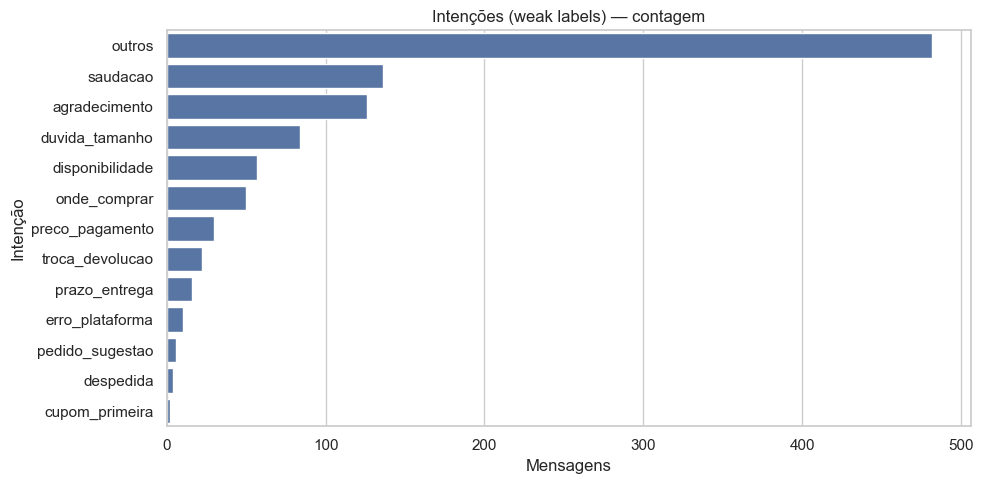

=== Amostras por classe (até 2 por intenção) ===


,texto,label_regra
0,Muito obrigada!,agradecimento
1,"ok, muito obrigada 😊",agradecimento
2,Olá! Tudo bem? Tem cupom para 1a compra?,cupom_primeira
3,olá! tudo bem? tem cupom para 1a compra?,cupom_primeira
4,até agora nada!,despedida
5,Beijos,despedida
6,não tem um link de comunicação no whatsapp,disponibilidade
7,"não gosto de nada apertado, mas essa blusa tem um shane mais ajustado. daí fiquei na dúvida.",disponibilidade
8,Boa noite ! Haverá reposição da saia única preta no tamanho 1 ?,duvida_tamanho
9,"oi bia, tudo bem? adorei a @curadabia, (o nome ficou demais), e claro ja fui olhar as peças! não localizei tabela de medidas! porem, pelo tamanho das peças que vc veste o g provavelmente não vai c...",duvida_tamanho


In [45]:
# CÉLULA 18 — Distribuição por intenção (weak) + barplot + amostras

dist = (
    df_cli["label_regra"]
    .value_counts(dropna=False)
    .rename_axis("intencao")
    .reset_index(name="qtd")
    .sort_values("qtd", ascending=False)
)
dist["%"] = (dist["qtd"] / dist["qtd"].sum() * 100).round(1)

print("=== Distribuição por intenção (weak labels) ===")
display(dist)

plt.figure(figsize=(10,5))
sns.barplot(data=dist, x="qtd", y="intencao")
plt.title("Intenções (weak labels) — contagem")
plt.xlabel("Mensagens"); plt.ylabel("Intenção")
plt.tight_layout()
try: plt.savefig(OUTDIR / "dist_intencoes_cliente.png", dpi=150, bbox_inches="tight")
except: pass
plt.show()

amostras_list = []
for lab, g in df_cli.groupby("label_regra"):
    if len(g) == 0: 
        continue
    take = min(2, len(g))
    amostras_list.append(g.sample(n=take, random_state=42)[["texto"]].assign(label_regra=lab))
amostras = pd.concat(amostras_list, ignore_index=True)
print("=== Amostras por classe (até 2 por intenção) ===")
display(amostras.head(20))

dist.to_csv(OUTDIR / "distribuicao_intencoes.csv", index=False)


In [46]:
# CÉLULA 19 — Dicionário de dados e relatório de qualidade

def data_dict(df_in: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for c in df_in.columns:
        s = df_in[c]
        rows.append({
            "coluna": c,
            "dtype": str(s.dtype),
            "n": int(s.size),
            "missing": int(s.isna().sum()),
            "%_missing": round(100*s.isna().mean(),2),
            "exemplo": str(s.dropna().astype(str).head(1).values[0]) if s.dropna().size else ""
        })
    return pd.DataFrame(rows).sort_values("coluna")

def quality_report(df_in: pd.DataFrame) -> dict:
    rep = {
        "n_linhas": int(len(df_in)),
        "n_colunas": int(df_in.shape[1]),
        "n_autores": int(df_in.get("autor", pd.Series()).nunique()) if "autor" in df_in else None,
        "periodo": str(df_in.get("ts", pd.Series()).min()) + " → " + str(df_in.get("ts", pd.Series()).max()) if "ts" in df_in else None,
        "pct_ruido": round(100*df_in.get("flag_ruido", pd.Series([False]*len(df_in))).mean(),2),
        "pct_pt": round(100*df_in.get("lang", pd.Series()).eq("pt").mean(),2) if "lang" in df_in else None,
        "len_tokens_media": round(df_in.get("len_tokens", pd.Series([0]*len(df_in))).mean(),2),
        "len_tokens_p95": float(df_in.get("len_tokens", pd.Series([0]*len(df_in))).quantile(0.95)),
    }
    return rep

for nm, d in [("clientes", df_cli_pp), ("time", df_resp_pp)]:
    if d.empty: 
        continue
    dd = data_dict(d)
    rep = quality_report(d)
    dd.to_csv(OUTDIR / f"{nm}_data_dictionary.csv", index=False)
    with open(OUTDIR / f"{nm}_quality_report.json", "w", encoding="utf-8") as f:
        json.dump(rep, f, ensure_ascii=False, indent=2)
    print(f"✓ Dicionário/Quality salvos para {nm}.")
    display(dd.head(10))
    print(rep)


✓ Dicionário/Quality salvos para clientes.


,coluna,dtype,n,missing,%_missing,exemplo
4,arquivo_origem,object,1025,0,0.0,Consolidação das mensagens do INSTAGRAM.csv
1,autor,object,1025,0,0.0,biapaesdebarros_1418872999507501
6,dia,object,1025,0,0.0,2024-07-02
8,flag_ruido,bool,1025,0,0.0,False
5,lado,object,1025,0,0.0,cliente
9,lang,object,1025,0,0.0,und
13,len_tokens,int64,1025,0,0.0,0
10,lscore,float64,1025,0,0.0,0.0
12,mensagem_lemma,object,1025,207,20.2,
11,mensagem_norm,object,1025,0,0.0,😍


{'n_linhas': 1025, 'n_colunas': 14, 'n_autores': 391, 'periodo': '2024-07-02 12:29:00.000 → 2025-05-19 13:50:01.437', 'pct_ruido': np.float64(0.0), 'pct_pt': np.float64(65.37), 'len_tokens_media': np.float64(4.66), 'len_tokens_p95': 19.799999999999955}
✓ Dicionário/Quality salvos para time.


,coluna,dtype,n,missing,%_missing,exemplo
4,arquivo_origem,object,974,0,0.00,Consolidação das mensagens do INSTAGRAM.csv
1,autor,object,974,0,0.00,emiliafreitas_1320876775966156
6,dia,object,974,0,0.00,2024-07-08
8,flag_ruido,bool,974,0,0.00,False
5,lado,object,974,0,0.00,time
9,lang,object,974,0,0.00,pt
13,len_tokens,int64,974,0,0.00,30
10,lscore,float64,974,0,0.00,1.0
12,mensagem_lemma,object,974,107,10.99,emil bem agradec demal feedback pod cert preocup tend segu busc marc trag opç grad represent mai númer corp possível tabel med busc ajust inform segu aprimor cad vez bjo
11,mensagem_norm,object,974,0,0.00,"olá emilia, boa noite! tudo bem? agradecemos demais o feedback e pode ter certeza que uma das preocupações que estamos tendo é seguir na busca por marcas que tragam opções e grades que representam..."


{'n_linhas': 974, 'n_colunas': 14, 'n_autores': 187, 'periodo': '2024-07-02 15:29:44.882 → 2025-05-19 14:24:34.886', 'pct_ruido': np.float64(0.0), 'pct_pt': np.float64(78.64), 'len_tokens_media': np.float64(9.79), 'len_tokens_p95': 32.0}


In [47]:
# CÉLULA 20 — Gera requirements do ambiente atual (pip freeze)

import subprocess, sys
req_path = OUTDIR / "requirements_notebook03.txt"
try:
    out = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True)
    with open(req_path, "w", encoding="utf-8") as f:
        f.write(out)
    print("✓ Requirements salvos em:", req_path)
except Exception as e:
    print("Aviso: não foi possível salvar requirements:", str(e))


✓ Requirements salvos em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook03_outputs\requirements_notebook03.txt


In [48]:
# CÉLULA 21 — Exporta dataset rotulado e resumo

out_path = OUTDIR / "mensagens_preprocessadas_rotuladas.csv"
df_cli.to_csv(out_path, index=False)

resumo_cols = ["ts","autor","texto","origem","label_regra","candidatos"]
df_cli[resumo_cols].to_csv(OUTDIR / "mensagens_rotulos_resumo.csv", index=False)

print("✓ Export concluído:")
print(" -", out_path)
print(" -", OUTDIR / "mensagens_rotulos_resumo.csv")
print(" -", OUTDIR / "distribuicao_intencoes.csv")


✓ Export concluído:
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook03_outputs\mensagens_preprocessadas_rotuladas.csv
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook03_outputs\mensagens_rotulos_resumo.csv
 - c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\notebook03_outputs\distribuicao_intencoes.csv


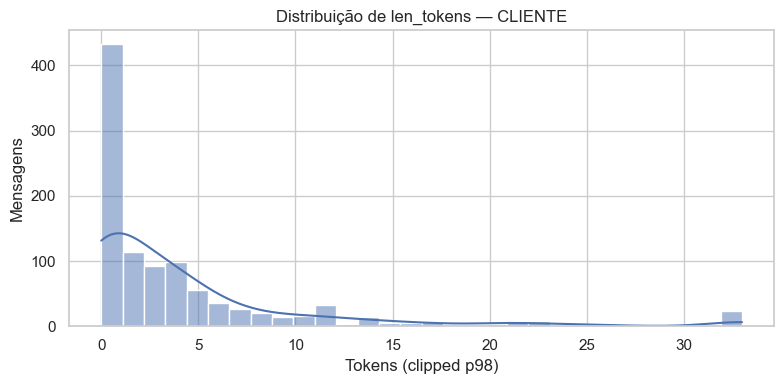

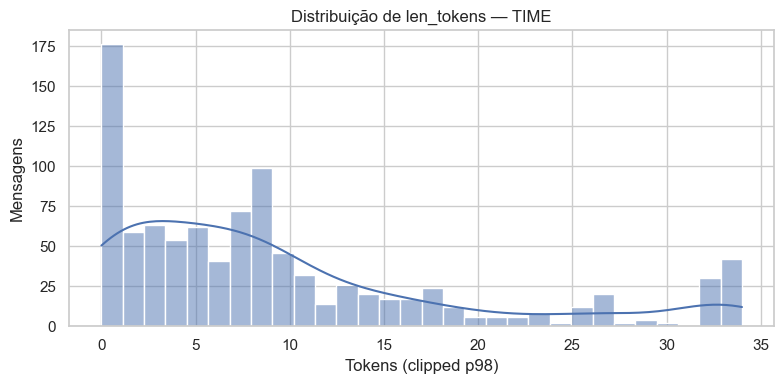

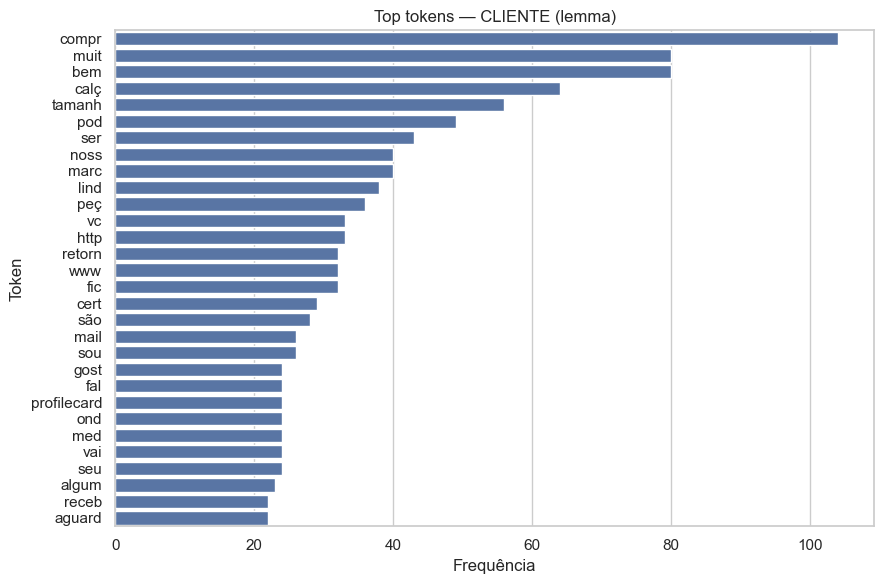

✓ Top tokens (cliente) salvos.


In [49]:
# CÉLULA 22 — Visuais de pré-processamento (len_tokens + top tokens do cliente)

sns.set_theme(style="whitegrid")

def plot_len_tokens(df_in: pd.DataFrame, titulo: str, fname: str):
    if df_in.empty or "len_tokens" not in df_in:
        return
    plt.figure(figsize=(8,4))
    sns.histplot(df_in["len_tokens"].clip(upper=df_in["len_tokens"].quantile(0.98)),
                 bins=30, kde=True)
    plt.title(titulo); plt.xlabel("Tokens (clipped p98)"); plt.ylabel("Mensagens")
    plt.tight_layout()
    try: plt.savefig(OUTDIR / fname, dpi=150, bbox_inches="tight")
    except: pass
    plt.show()

def top_tokens(df_in: pd.DataFrame, k=30):
    if "mensagem_lemma" not in df_in:
        return
    vc = (df_in["mensagem_lemma"].fillna("")
          .str.split().explode().value_counts().head(k).reset_index())
    vc.columns = ["token","freq"]
    plt.figure(figsize=(9,6))
    sns.barplot(data=vc, x="freq", y="token")
    plt.title("Top tokens — CLIENTE (lemma)")
    plt.xlabel("Frequência"); plt.ylabel("Token")
    plt.tight_layout()
    try: plt.savefig(OUTDIR / "top_tokens_cliente.png", dpi=150, bbox_inches="tight")
    except: pass
    plt.show()
    vc.to_csv(OUTDIR / "top_tokens_cliente.csv", index=False)
    print("✓ Top tokens (cliente) salvos.")

plot_len_tokens(df_cli_pp, "Distribuição de len_tokens — CLIENTE", "dist_len_tokens_cliente.png")
plot_len_tokens(df_resp_pp, "Distribuição de len_tokens — TIME", "dist_len_tokens_time.png")
top_tokens(df_cli_pp)


In [50]:
# CÉLULA 23 — Checklist final de artefatos gerados (nome, data, tamanho, linhas se CSV)

rows = []
for p in sorted(Path(OUTDIR).glob("*")):
    if not p.is_file():
        continue
    mod  = dt.datetime.fromtimestamp(p.stat().st_mtime).strftime("%Y-%m-%d %H:%M")
    size = f"{p.stat().st_size/1024:.1f} KB"
    extra = ""
    if p.suffix.lower() == ".csv":
        try:
            n = sum(1 for _ in open(p, "r", encoding="utf-8", errors="ignore")) - 1
            extra = f"{n} linhas"
        except Exception:
            pass
    rows.append([p.name, mod, size, extra])

chk = pd.DataFrame(rows, columns=["arquivo","modificado","tamanho","info"]).sort_values("arquivo")
display(chk)


,arquivo,modificado,tamanho,info
0,clientes_data_dictionary.csv,2025-09-23 20:03,0.6 KB,14 linhas
1,clientes_quality_report.json,2025-09-23 20:03,0.2 KB,
2,clientes_test.csv,2025-09-23 20:03,31.9 KB,103 linhas
3,clientes_train.csv,2025-09-23 20:03,249.9 KB,819 linhas
4,clientes_valid.csv,2025-09-23 20:03,32.7 KB,103 linhas
5,dist_intencoes_cliente.png,2025-09-23 20:03,69.8 KB,
6,dist_len_tokens_cliente.png,2025-09-23 20:03,40.9 KB,
7,dist_len_tokens_time.png,2025-09-23 20:03,46.4 KB,
8,distribuicao_intencoes.csv,2025-09-23 20:03,0.3 KB,13 linhas
9,heatmap_dia_hora_cliente.png,2025-09-23 20:03,40.2 KB,
